# [2주차 과제] 지도학습 모델의 회귀 및 분류 성능 비교 - 25기 이유민

## 과제 목표
- 선형 모델의 한계를 확인하고, 비선형 모델(SVR, Decision Tree, Ensemble)의 성능을 비교합니다.
- 지표 해석, 규제(Regularization), Bias-Variance에 대해 학습합니다.

## 데이터셋
- 회귀: California Housing
- 분류: Wine


## 제출 지침
- 원활한 의존성 라이브러리 사용을 위해 코랩 환경에서 진행하시는 것을 권장합니다.
- 각 문항 아래 코드 셀을 실행하고, `TODO` 주석이 있는 곳을 작성하세요.
    - '___' 부분에 알맞은 코드를 작성하시면 됩니다.
- 문항별 해석(서술형) 문항은 마크다운 셀('답안'으로 명시된 부분)에 작성하세요.


In [1]:
# 공통 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report

# 스타일 및 난수 시드값 고정
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [2]:
# 데이터 로드

# 회귀 문제용 데이터
housing = fetch_california_housing(as_frame=True)
X_reg = housing.data.copy()
y_reg = housing.target.copy()

# 분류 문제용 데이터
wine = load_wine(as_frame=True)
X_clf = wine.data.copy()
y_clf = wine.target.copy()

print('회귀 데이터:', X_reg.shape, y_reg.shape)
print('분류 데이터:', X_clf.shape, y_clf.shape)

회귀 데이터: (20640, 8) (20640,)
분류 데이터: (178, 13) (178,)


## [Section 1] EDA & Preprocessing

### 문제 1
1. 상관관계 Heatmap을 시각화하세요.
2. 타겟과 절대 상관계수가 가장 높은 특성 2개를 확인해보세요.


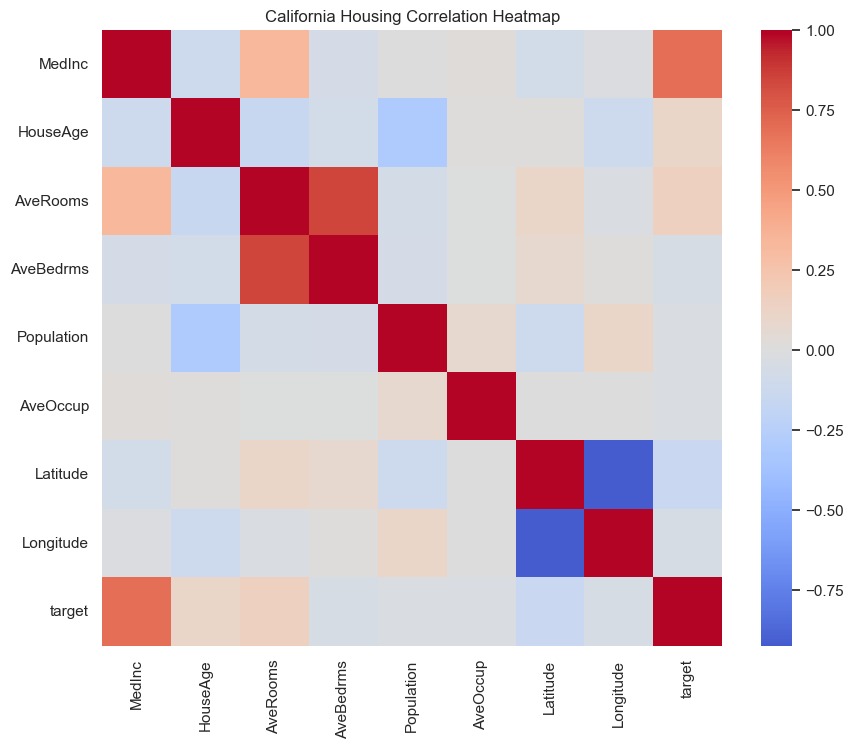

타겟과 상관계수 상위 2개 특성:
MedInc      0.688075
AveRooms    0.151948
Name: target, dtype: float64


In [3]:
# 문제 1: 회귀 데이터 상관관계 분석
reg_df = X_reg.copy()
reg_df['target'] = y_reg

# TODO 1) 상관계수 행렬 계산 메서드
corr = reg_df.corr(numeric_only=True)

# TODO 2) Heatmap 입력 데이터
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('California Housing Correlation Heatmap')
plt.show()

# TODO 3) target과 절대 상관계수 상위 2개 특성 추출
top2 = corr['target'].drop('target').abs().sort_values(ascending=False).head(2)
print('타겟과 상관계수 상위 2개 특성:')
print(top2)


### 문제 1 해석 작성
- (작성) 선택한 2개 특성이 타겟과 연관성이 높은 이유를 데이터셋을 고려하여 추론해보세요.

**답안:** 소득 수준이 높을수록 더 높은 주거 비용을 지불할 능력이 있으며, 이는 해당 지역의 부동산 수요와 가격 상승으로 이어지므로 해당 지역 가구 소득과 주택 가격 사이에는 강한 양의 상관관계가 형성될 것이다. 또한, 주택의 규모 역시 해당 지역에 대형 평수의 주택이나 단독 주택 분포를 시사하며 이는 건축 비용 및 토지 가치와 직결되어 주택 가격을 결정하는 핵심 지표가 된 것으로 추론할 수 있다.



### 문제 2
1. `StandardScaler`로 표준화를 적용하세요.
2. 선형 모델/SVM에서 표준화가 중요한 이유를 서술하세요.


In [4]:
# 문제 2: 회귀 데이터 분할 + 표준화
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
# TODO 4) 학습 데이터에 적용할 메서드
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
# TODO 5) 테스트 데이터에 적용할 메서드
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print('표준화 완료:', X_train_reg_scaled.shape, X_test_reg_scaled.shape)


표준화 완료: (16512, 8) (4128, 8)


### 문제 2 해석 작성
- (작성) 선형 모델에서 스케일 차이가 학습 안정성에 미치는 영향
- (작성) SVM/SVR에서 거리 기반 계산과 커널 값에 스케일이 주는 영향

**답안:** 
- 선형 모델은 경사하강법을 통해 최적의 가중치를 찾는데, 특정 특성의 수치 범위가 지나치게 크면 해당 방향으로의 기울기가 과도하게 계산되어 최적점을 제대로 찾기가 어렵고, 가중치의 절대적인 크기가 특성의 중요도가 아닌 단순 수치 범위에 의존하게 되어 모델의 해석력이 떨어지게 된다.
- SVM은 데이터 포인트 사이의 거리를 계산하여 최적의 결정 경계를 찾는 알고리즘인데, 거리 계산 시 수치 범위가 큰 특성이 결과에 압도적인 영향을 미치게 된다면 모델이 작은 범위를 가진 유의미한 특성을 무시하게 만든다. 또한, 커널 함수 사용 시에도 입력값의 스케일이 커널값에 직접적인 영향을 주어 모델이 데이터의 복잡한 패턴을 제대로 학습하지 못하고 성능이 저하될 수 있다.



## [Section 2] Linear vs Non-linear

### 문제 3 (회귀)
`LinearRegression` vs `SVR` 성능 비교 및 산점도 작성


In [5]:
# 문제 3: 모델 학습
lr = LinearRegression()
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)

# TODO 6) LinearRegression 학습 메서드
lr.fit(X_train_reg_scaled, y_train_reg)
# TODO 7) SVR 학습 메서드
svr.fit(X_train_reg_scaled, y_train_reg)

# TODO 8) LinearRegression 예측 메서드
pred_lr = lr.predict(X_test_reg_scaled)
# TODO 9) SVR 예측 메서드
pred_svr = svr.predict(X_test_reg_scaled)

result_q3 = pd.DataFrame({
    'Model': ['LinearRegression', 'SVR(rbf)'],
    'MSE': [mean_squared_error(y_test_reg, pred_lr), mean_squared_error(y_test_reg, pred_svr)],
    # TODO 10) R2 계산 시 SVR 예측값 변수
    'R2': [r2_score(y_test_reg, pred_lr), r2_score(y_test_reg, pred_svr)]
})
result_q3


,Model,MSE,R2
0,LinearRegression,0.555892,0.575788
1,SVR(rbf),0.323697,0.752980


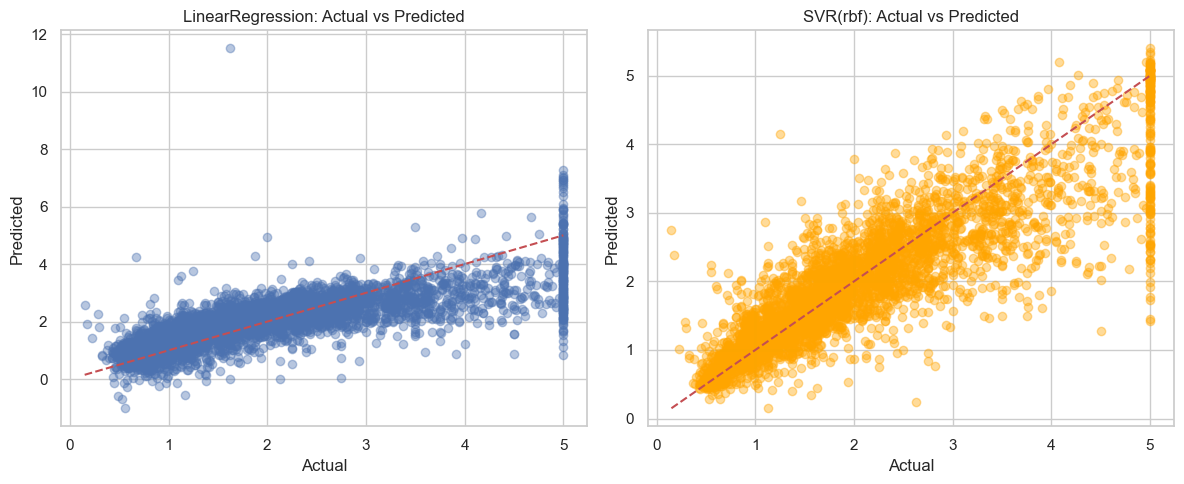

In [6]:
# 문제 3: 산점도 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_reg, pred_lr, alpha=0.4)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
axes[0].set_title('LinearRegression: Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test_reg, pred_svr, alpha=0.4, color='orange')
axes[1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
axes[1].set_title('SVR(rbf): Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()


### 문제 3 해석 작성
- (작성) 선형 모델의 한계가 드러난 패턴
- (작성) SVR 성능 개선 이유(비선형 함수 언급)

**답안:**
선형 모델의 결과를 살펴보면, 예측값들이 회귀선 주위로 넓게 퍼져 있으며, 특히 실제 주택 가격이 높아질수록 예측값의 오차가 커지는 경향을 보인다. 이는 주택 데이터의 복잡한 변수 간 관계를 단순 선형 결합만으로는 충분히 설명할 수 없음을 의미한다.
반면, SVR의 산점도는 데이터가 이상적인 예측선 부근에 조밀하게 모여 있는 양상을 보인다. 이는 SVR이 선형 모델이 잡아내지 못한 복잡하고 굴곡진 비선형적 관계를 효과적으로 학습했기 때문이다. 이를 통해 주택 가격 결정 요인들의 상호작용을 모델링하는 데 비선형 함수를 사용하는 SVR이 훨씬 성능이 좋다는 것을 확인할 수 있다.


### 문제 4
SVR의 `C`, `epsilon`을 바꿔 성능 변화를 관찰하고, 과적합 방지 전략을 설명하세요.


In [7]:
# 문제 4: 하이퍼파라미터 실험
C_list = [1, 10, 50]
eps_list = [0.01, 0.1, 0.3]

rows = []
for c in C_list:
    for eps in eps_list:
        # TODO 11) 루프 변수 c, eps를 SVR에 적용
        model = SVR(kernel='rbf', C=c, epsilon=eps)
        model.fit(X_train_reg_scaled, y_train_reg)
        pred = model.predict(X_test_reg_scaled)
        rows.append({
            'C': c,
            'epsilon': eps,
            'MSE': mean_squared_error(y_test_reg, pred),
            'R2': r2_score(y_test_reg, pred)
        })

# TODO 12) R2 기준 내림차순
svr_grid_result = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
svr_grid_result


,C,epsilon,MSE,R2
0,50,0.30,0.309483,0.763827
1,50,0.10,0.316295,0.758629
2,50,0.01,0.318321,0.757083
3,10,0.30,0.319304,0.756333
4,10,0.10,0.323697,0.752980
5,10,0.01,0.324228,0.752575
6,1,0.30,0.352804,0.730768
7,1,0.10,0.357004,0.727563
8,1,0.01,0.357802,0.726954


### 문제 4 해석 작성
- (작성) `C` 증가/감소가 편향 및 분산에 미치는 영향
- (작성) `epsilon` 변화가 예측 민감도에 미치는 영향
- (작성) 결론 작성(과적합 방지 전략)

**답안:** C가 증가할수록 모델은 학습 데이터의 오차에 더 엄격한 패널티를 부과하여 편향을 줄이지만, 모델이 과도하게 복잡해지면서 분산이 커져 과적합의 위험이 높아진다. epsilon이 작아질수록 모델은 미세한 오차에도 민감하게 반응하여 예측의 정교함은 올라가나 노이즈까지 학습할 가능성이 커진다. 따라서 효과적인 과적합 방지를 위해서는 무조건적인 오차 최소화보다는 교차 검증을 통해 적절한 수준의 C 값, epsilon 값을 설정하여 모델의 복잡도와 일반화 성능 간 최적의 균형을 찾아야 한다.



## [Section 3] Decision Tree & Ensemble

### 문제 5
`DecisionTreeRegressor` vs `RandomForestRegressor` 성능 비교


In [8]:
# 문제 5: Bagging 비교
dt = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)

# TODO 13) DecisionTree 학습 메서드
dt.fit(X_train_reg, y_train_reg)
# TODO 14) RandomForest 학습 메서드
rf.fit(X_train_reg, y_train_reg)
pred_dt = dt.predict(X_test_reg)
pred_rf = rf.predict(X_test_reg)

result_q5 = pd.DataFrame({
    'Model': ['DecisionTreeRegressor', 'RandomForestRegressor'],
    'MSE': [mean_squared_error(y_test_reg, pred_dt), mean_squared_error(y_test_reg, pred_rf)],
    'R2': [r2_score(y_test_reg, pred_dt), r2_score(y_test_reg, pred_rf)]
})
result_q5


,Model,MSE,R2
0,DecisionTreeRegressor,0.422045,0.677928
1,RandomForestRegressor,0.272759,0.791852


### 문제 5 해석 작성
- (작성) 왜 Random Forest가 단일 트리보다 Variance를 줄이는가?
- (작성) Diversity Theorem 관점에서 샘플 및 특성 랜덤성의 역할

**답안:**
- 단일 트리는 학습 데이터의 미세한 변화에도 민감하게 반응하여 과적합될 가능성이 큰 반면, 랜덤 포레스트는 수많은 독립적인 트리를 학습시킨 뒤 그 결과의 평균을 취하는 배깅 방식을 통해 개별 트리의 오차와 변동성을 상쇄시킴으로써 모델의 전체적인 분산을 낮춘다.
- 샘플링과 특성 랜덤 선택은 개별 트리들이 서로 다른 데이터를 학습하게 하여 모델 간 다양성을 확보한다. 다양성은 개별 트리들이 서로 다른 오류를 범하도록 유도하며, 이들을 결합했을 때 단일 모델보다 훨씬 일반화된 예측 성능을 갖도록 한다.


### 문제 6
Boosting 성능 비교 및 Residual 학습 원리


In [9]:
# 문제 6: Boosting
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.05, max_depth=3)

# TODO 15) GradientBoosting 학습 메서드
gbr.fit(X_train_reg, y_train_reg)
# TODO 16) GradientBoosting 예측 메서드
pred_gbr = gbr.predict(X_test_reg)

result_q6 = pd.DataFrame({
    'Model': ['LinearRegression', 'SVR(rbf)', 'DecisionTreeRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor'],
    'MSE': [
        mean_squared_error(y_test_reg, pred_lr),
        mean_squared_error(y_test_reg, pred_svr),
        mean_squared_error(y_test_reg, pred_dt),
        mean_squared_error(y_test_reg, pred_rf),
        mean_squared_error(y_test_reg, pred_gbr)
    ],
    'R2': [
        r2_score(y_test_reg, pred_lr),
        r2_score(y_test_reg, pred_svr),
        r2_score(y_test_reg, pred_dt),
        r2_score(y_test_reg, pred_rf),
        r2_score(y_test_reg, pred_gbr)
    ]
}).sort_values('R2', ascending=False).reset_index(drop=True)
result_q6


,Model,MSE,R2
0,RandomForestRegressor,0.272759,0.791852
1,GradientBoostingRegressor,0.291214,0.777768
2,SVR(rbf),0.323697,0.752980
3,DecisionTreeRegressor,0.422045,0.677928
4,LinearRegression,0.555892,0.575788


### 문제 6 해석 작성
- (작성) GBM이 이전 단계 잔차를 어떤 방식으로 학습하는지 단계별로 설명
- (작성) 위 실험에서의 GBM과 랜덤포레스트의 성능(R2) 차이를 Bias-Variance Trade-off로 해석

**답안:**
- GBM은 약한 학습기를 순차적으로 결합하는데, 초기 모델에서 실제값과 예측값 사이의 잔차가 발생했을 때, 다음 단계 모델은 이전 단계 잔차를 직접 학습하여 이전 모델의 실수를 보완한다. 이 과정을 반복해 새로운 모델이 추가될 때마다 전체 모델의 잔차가 점점 줄어들게 된다.
- 랜덤포레스트는 독립적인 트리들을 평균 내어 모델의 분산을 줄이는 데 집중하는 배깅 방식인 반면, GBM은 이전 트리의 오차를 지속적으로 수정해 나가며 모델의 편향을 낮추는 데 집중한다.


## [Section 4] 결론 및 분석

### 문제 7
분류 문제에서 Accuracy가 아닌 F1-score가 중요한 상황을 확인하세요.


In [10]:
# 문제 7: 분류
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE,
    # TODO 17) 클래스 비율 유지를 위한 설정
    stratify=y_clf
)

scaler_clf = StandardScaler()
# TODO 18) 분류 데이터 학습 스케일링 메서드
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

from sklearn.ensemble import RandomForestClassifier
clf_model = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300)
clf_model.fit(X_train_clf, y_train_clf)
pred_clf = clf_model.predict(X_test_clf)

print('Accuracy:', accuracy_score(y_test_clf, pred_clf))
print('F1-macro:', f1_score(y_test_clf, pred_clf, average='macro'))
print('F1-weighted:', f1_score(y_test_clf, pred_clf, average='weighted'))
print('\nClassification Report\n', classification_report(y_test_clf, pred_clf))


Accuracy: 1.0
F1-macro: 1.0
F1-weighted: 1.0

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### 문제 7 해석 작성
- (작성) Accuracy가 왜 클래스 불균형 데이터에서 왜곡될 수 있는지
- (작성) F1-score를 Accuracy보다 우선 확인해야 하는 상황 예시 (앞 문항과 연결하여 작성)

**답안:**
- Accuracy는 전체 데이터 중 맞게 예측한 비율을 나타내는데, 이때 모든 클래스의 예측 결과를 단순히 합산하여 계산하므로 데이터 수가 많은 다수 클래스의 영향력에 매몰되는 한계가 있다. 따라서 불균형 데이터에서는 소수 클래스에 대한 식별력이 현저히 낮아져 왜곡을 발생시킨다.
- 따라서 사기 거래 탐지 등 소수의 이상 케이스를 놓치지 않는 것이 매우 중요한 상황에서는 F1-score를 확인해야 한다. 다수 클래스에만 치중된 모델의 편향성을 적나라하게 보여주고, 불균형한 환경에서도 모델이 만든 클래스를 고르게 잘 분류하고 있는지 객관적으로 평가 가능하기 때문이다.


### 문제 8
최종 선택 모델의 Feature Importance를 출력하고 도메인 관점으로 왜 이러한 결과가 나왔는지 생각해보세요 ^ㅡ^


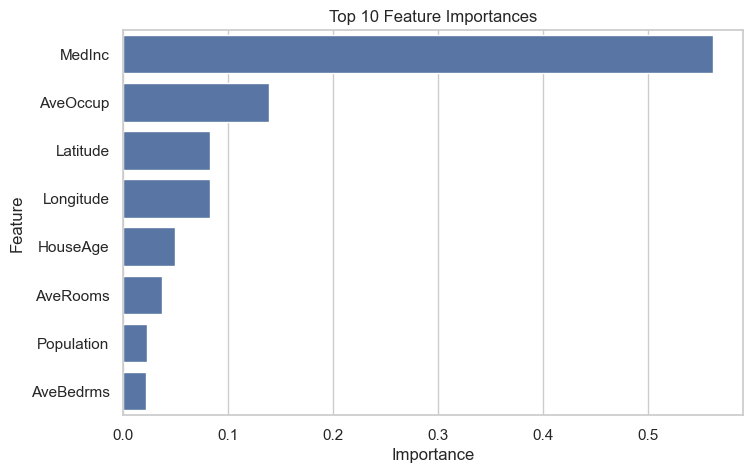

MedInc        0.561583
AveOccup      0.138812
Latitude      0.083399
Longitude     0.083280
HouseAge      0.050154
AveRooms      0.037396
Population    0.022901
AveBedrms     0.022474
dtype: float64

In [11]:
# 문제 8: 특성 중요도 시각화
final_model = rf
importance = pd.Series(final_model.feature_importances_, index=X_train_reg.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values[:10], y=importance.index[:10], orient='h')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

importance.head(10)


## 제출 전 체크리스트
- [ ] Section 1~4 모든 코드 작성 및 실행
- [ ] 서술형 문항 답안 작성


긴 과제 진행하시느라 정말 고생 많으셨습니다.

코드작성과 해석을 스스로 정리해보신 만큼, 지도학습 핵심 개념을 탄탄하게 가져가는 기회가 되셨으면 합니다.
감사합니다.
